# Pronostia Anomaly Detection — Analyse comparative 6 modèles

Scénario : `by_condition` / `refit` — 3 tâches (Condition 1 → 2 → 3)

| Exp | Modèle | Dataset |
|-----|--------|---------|
| exp_137 | HDC | pronostia |
| exp_138 | TinyOL AE | pronostia |
| exp_139 | KMeans | pronostia |
| exp_140 | Mahalanobis | pronostia |
| exp_141 | DBSCAN | pronostia |
| exp_142 | EWC one-class | pronostia |

**Dépendances** : S15-03 → S15-08

**Figures générées** : `notebooks/figures/cl_evaluation/anomaly_detection/pronostia/`

## Section 1 — Setup & chargement résultats

In [1]:
import json
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

REPO_ROOT = pathlib.Path("../../..")
if str(REPO_ROOT.resolve()) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT.resolve()))

FIG_DIR = REPO_ROOT / "notebooks/figures/cl_evaluation/anomaly_detection/pronostia"
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HDC", "TinyOL AE", "KMeans", "Mahalanobis", "DBSCAN", "EWC one-class"]
MODEL_KEYS = ["hdc", "tinyol_ae", "kmeans", "mahalanobis", "dbscan", "ewc_oneclass"]
TASK_LABELS = ["C1 (1800 rpm)", "C2 (1650 rpm)", "C3 (1500 rpm)"]
N_TASKS = 3

COLORS = {
    "HDC":           "#ff7f0e",
    "TinyOL AE":     "#2ca02c",
    "KMeans":        "#d62728",
    "Mahalanobis":   "#9467bd",
    "DBSCAN":        "#8c564b",
    "EWC one-class": "#1f77b4",
}

MARKERS = {
    "HDC":           "o",
    "TinyOL AE":     "s",
    "KMeans":        "^",
    "Mahalanobis":   "D",
    "DBSCAN":        "v",
    "EWC one-class": "P",
}

# Expériences Pronostia by_condition refit
PRONOSTIA_EXP = {
    "HDC":           "exp_137",
    "TinyOL AE":     "exp_138",
    "KMeans":        "exp_139",
    "Mahalanobis":   "exp_140",
    "DBSCAN":        "exp_141",
    "EWC one-class": "exp_142",
}

# Expériences Monitoring by_location refit (6 modèles, 4D)
MONITORING_EXP = {
    "HDC":           "exp_131",
    "TinyOL AE":     "exp_132",
    "KMeans":        "exp_133",
    "Mahalanobis":   "exp_134",
    "DBSCAN":        "exp_135",
    "EWC one-class": "exp_136",
}


def load_metrics(exp_id: str) -> dict:
    path = REPO_ROOT / f"experiments/{exp_id}/results/metrics_anomaly.json"
    with open(path) as f:
        d = json.load(f)
    # Charger auroc_matrix depuis .npy (plus fiable que le JSON avec null → NaN)
    mat_path = REPO_ROOT / f"experiments/{exp_id}/results/auroc_matrix.npy"
    if mat_path.exists():
        d["_auroc_matrix_npy"] = np.load(mat_path)  # shape [3,3], NaN upper triangle
    else:
        mat_raw = d["auroc_matrix"]
        d["_auroc_matrix_npy"] = np.array(
            [[v if v is not None else np.nan for v in row] for row in mat_raw],
            dtype=float,
        )
    if "auroc_per_task_final" not in d:
        mat = d["_auroc_matrix_npy"]
        n = d["n_tasks"]
        d["auroc_per_task_final"] = [mat[n - 1, j] for j in range(n)]
    return d


prost = {m: load_metrics(exp) for m, exp in PRONOSTIA_EXP.items()}
monit = {m: load_metrics(exp) for m, exp in MONITORING_EXP.items()}

print("Expériences Pronostia chargées :")
for m, d in prost.items():
    ok = "✓" if d.get("ram_peak_bytes", 0) <= 65536 else "✗"
    print(f"  {m:15s}  avg_auroc={d['avg_auroc']:.4f}  RAM={d.get('ram_peak_bytes', 'N/A')} B {ok}")

Expériences Pronostia chargées :
  HDC              avg_auroc=0.7231  RAM=15272 B ✓
  TinyOL AE        avg_auroc=0.7268  RAM=1992 B ✓
  KMeans           avg_auroc=0.7402  RAM=5698 B ✓
  Mahalanobis      avg_auroc=0.6673  RAM=1756 B ✓
  DBSCAN           avg_auroc=0.7034  RAM=201746 B ✗
  EWC one-class    avg_auroc=0.7165  RAM=1480 B ✓


## Section 2 — Tableau AUROC synthèse (6 modèles × 3 tâches + métriques CL)

Tableau synthèse — Pronostia by_condition / refit (failure_ratio=10%)
               avg AUROC  Oubli (AF)     BWT  RAM (Ko)  Latence (ms)  n params
Modèle                                                                        
HDC               0.7231     -0.0176  0.0176      14.9        0.1202      1024
TinyOL AE         0.7268      0.1835 -0.1835       1.9        0.1163      2229
KMeans            0.7402      0.0271 -0.0271       5.6        0.2798        39
Mahalanobis       0.6673      0.2045 -0.2045       1.7        0.0082       182
DBSCAN            0.7034      0.1061 -0.1061     197.0        0.3175     21567
EWC one-class     0.7165      0.1845 -0.1845       1.4        0.0867      2837


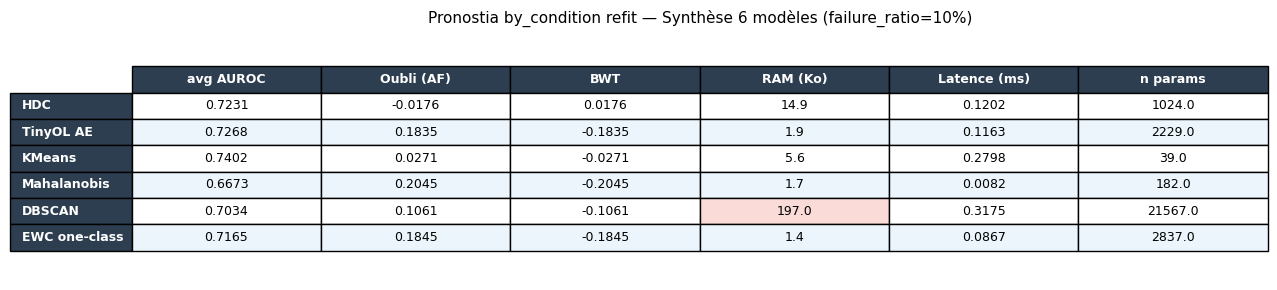

Sauvegardé : ../../../notebooks/figures/cl_evaluation/anomaly_detection/pronostia/auroc_table_full_pronostia.png

AUROC par tâche :
              C1 (1800 rpm) C2 (1650 rpm) C3 (1500 rpm) Moyenne
Modèle                                                         
HDC                  0.6450        0.7839        0.7404  0.7231
TinyOL AE            0.7009        0.6055        0.8740  0.7268
KMeans               0.7019        0.6440        0.8747  0.7402
Mahalanobis          0.6026        0.5202        0.8791  0.6673
DBSCAN               0.6861        0.5864        0.8378  0.7034
EWC one-class        0.7041        0.6180        0.8273  0.7165


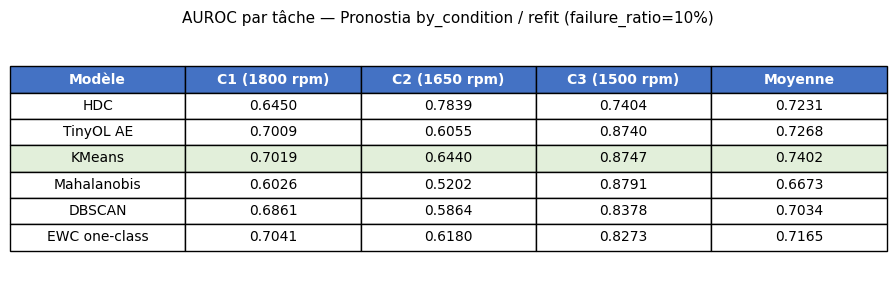

Sauvegardé : ../../../notebooks/figures/cl_evaluation/anomaly_detection/pronostia/auroc_table_pronostia.png


In [2]:
# --- Table synthèse complète : avg_auroc, AF, BWT, RAM, Latence, n_params ---
rows = []
for m in MODELS:
    d = prost[m]
    rows.append({
        "Modèle":       m,
        "avg AUROC":    round(d["avg_auroc"], 4),
        "Oubli (AF)":   round(d.get("auroc_forgetting", float("nan")), 4),
        "BWT":          round(d.get("auroc_bwt", float("nan")), 4),
        "RAM (Ko)":     round(d.get("ram_peak_bytes", 0) / 1024, 1),
        "Latence (ms)": round(d.get("inference_latency_ms", float("nan")), 4),
        "n params":     d.get("n_params", "N/A"),
    })

df_full = pd.DataFrame(rows).set_index("Modèle")
print("Tableau synthèse — Pronostia by_condition / refit (failure_ratio=10%)")
print(df_full.to_string())

fig, ax = plt.subplots(figsize=(13, 3))
ax.axis("off")
tbl = ax.table(
    cellText=df_full.values,
    colLabels=df_full.columns,
    rowLabels=df_full.index,
    cellLoc="center",
    loc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0 or col == -1:
        cell.set_facecolor("#2C3E50")
        cell.set_text_props(color="white", fontweight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#EBF5FB")
# Highlight RAM overshoot (DBSCAN)
for row_i, m in enumerate(MODELS, start=1):
    ram_ko = prost[m].get("ram_peak_bytes", 0) / 1024
    if ram_ko > 64:
        tbl[(row_i, 3)].set_facecolor("#FADBD8")   # col index 3 = RAM (Ko)

ax.set_title(
    "Pronostia by_condition refit — Synthèse 6 modèles (failure_ratio=10%)",
    fontsize=11, pad=10,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "auroc_table_full_pronostia.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé : {FIG_DIR / 'auroc_table_full_pronostia.png'}")

# --- Table AUROC per-task conservée pour compatibilité ---
rows_pt = []
for m in MODELS:
    d = prost[m]
    per_task = d["auroc_per_task_final"]
    row = {"Modèle": m}
    for i, tl in enumerate(TASK_LABELS):
        row[tl] = f"{per_task[i]:.4f}"
    row["Moyenne"] = f"{d['avg_auroc']:.4f}"
    rows_pt.append(row)

df_pt = pd.DataFrame(rows_pt).set_index("Modèle")
print("\nAUROC par tâche :")
print(df_pt.to_string())

fig2, ax2 = plt.subplots(figsize=(9, 3))
ax2.axis("off")
tbl2 = ax2.table(
    cellText=df_pt.reset_index().values,
    colLabels=["Modèle"] + list(df_pt.columns),
    loc="center",
    cellLoc="center",
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(10)
tbl2.scale(1.2, 1.5)
for j in range(len(df_pt.columns) + 1):
    tbl2[(0, j)].set_facecolor("#4472C4")
    tbl2[(0, j)].set_text_props(color="white", fontweight="bold")
best_model_idx = int(np.argmax([float(r["Moyenne"]) for r in rows_pt])) + 1
for j in range(len(df_pt.columns) + 1):
    tbl2[(best_model_idx, j)].set_facecolor("#E2EFDA")
ax2.set_title(
    "AUROC par tâche — Pronostia by_condition / refit (failure_ratio=10%)",
    fontsize=11, pad=10,
)
fig2.tight_layout()
fig2.savefig(FIG_DIR / "auroc_table_pronostia.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé : {FIG_DIR / 'auroc_table_pronostia.png'}")

## Section 2b — Évolution AUROC par tâche (matrices auroc_matrix)

Pour chaque modèle, la matrice AUROC [3×3] est tracée : l'axe X représente la tâche
apprise (T1→T3), chaque courbe représente l'AUROC sur une tâche donnée (C1, C2 ou C3).
Un effondrement de la courbe C1 après l'apprentissage de C2/C3 indique de l'oubli
catastrophique.

Les matrices sont chargées depuis `results/auroc_matrix.npy` (NaN pour upper triangle).
`sharey=False` et y-lim dynamique : AUROC Pronostia ~0.60–0.88 (pas ~1.0 comme CWRU).

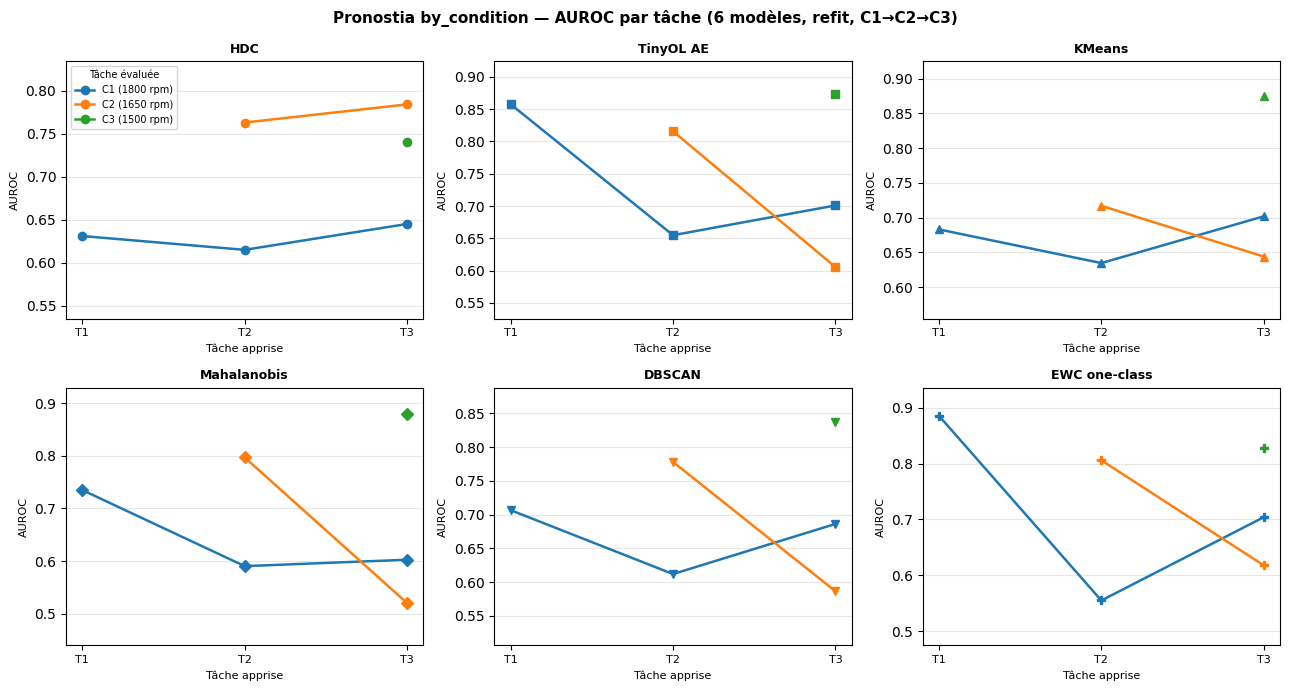

Sauvegardé : ../../../notebooks/figures/cl_evaluation/anomaly_detection/pronostia/auroc_per_task_pronostia.png


In [3]:
TASK_COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c"]  # C1, C2, C3

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharey=False)
axes = axes.flatten()

for idx, m in enumerate(MODELS):
    ax = axes[idx]
    mat = prost[m]["_auroc_matrix_npy"]  # shape [3,3], NaN upper triangle

    for task_j in range(N_TASKS):
        auroc_vals = []
        x_vals = []
        for i in range(task_j, N_TASKS):
            v = mat[i, task_j]
            if not np.isnan(v):
                auroc_vals.append(v)
                x_vals.append(i + 1)  # 1-indexed training step

        if auroc_vals:
            ax.plot(
                x_vals, auroc_vals,
                marker=MARKERS[m], markersize=6,
                label=TASK_LABELS[task_j], linewidth=1.8,
                color=TASK_COLORS[task_j],
            )

    ax.set_title(m, fontsize=9, fontweight="bold")
    ax.set_xlabel("Tâche apprise", fontsize=8)
    ax.set_ylabel("AUROC", fontsize=8)
    ax.set_xticks(range(1, N_TASKS + 1))
    ax.set_xticklabels([f"T{i + 1}" for i in range(N_TASKS)], fontsize=8)
    # Y-lim dynamique (AUROC Pronostia ~0.60–0.88)
    y_vals_all = mat[~np.isnan(mat)]
    if len(y_vals_all) > 0:
        ax.set_ylim(max(0.0, y_vals_all.min() - 0.08), min(1.02, y_vals_all.max() + 0.05))
    ax.grid(axis="y", alpha=0.3)
    if idx == 0:
        ax.legend(fontsize=7, title="Tâche évaluée", title_fontsize=7)

fig.suptitle(
    "Pronostia by_condition — AUROC par tâche (6 modèles, refit, C1→C2→C3)",
    fontsize=11, fontweight="bold",
)
plt.tight_layout()
fig.savefig(FIG_DIR / "auroc_per_task_pronostia.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé : {FIG_DIR / 'auroc_per_task_pronostia.png'}")

## Section 3 — Visualisation score d'anomalie dans le temps (Pronostia C1 Bearing 1)

Le score d'anomalie du meilleur modèle (KMeans) est tracé sur la séquence complète du
roulement C1 Bearing 1_1. Le score doit augmenter en fin de vie (dégradation progressive),
validant qualitativement la capacité de détection.

  [KMeans] Tâche 0 — K sélectionné : 2 (méthode=silhouette)
  [KMeans] Seuil calculé sur Task 0 : 2.2035 (percentile 95)


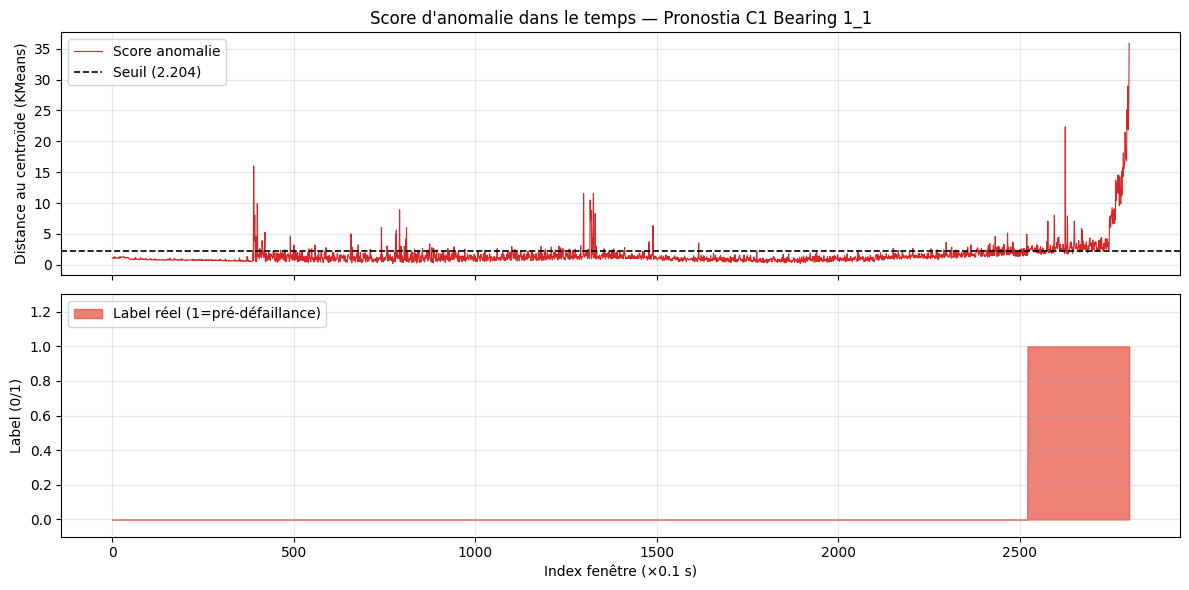

n_windows=2803, n_faulty=281.0, threshold=2.2035
Sauvegardé : ../../../notebooks/figures/cl_evaluation/anomaly_detection/pronostia/score_temporal_best_model.png


In [4]:
from pathlib import Path

NPY_DIR = REPO_ROOT / "data/raw/Pronostia dataset/binaries"
NORMALIZER_PATH = REPO_ROOT / "configs/pronostia_normalizer.yaml"

if not (NPY_DIR / "0.npy").exists():
    print("[SKIP] Fichiers .npy Pronostia introuvables — section 3 non exécutable")
    print(f"       Chemin attendu : {NPY_DIR.resolve()}")
else:
    from src.data.pronostia_dataset import (
        load_bearing_features,
        load_pronostia_normalizer,
        FAILURE_RATIO,
    )
    from src.models.unsupervised.kmeans_detector import KMeansDetector

    # Chargement séquence complète C1 Bearing 1_1
    X_full, y_full = load_bearing_features(
        NPY_DIR / "0.npy", failure_ratio=FAILURE_RATIO
    )

    # Normalisation Z-score (stats fittées sur Condition 1)
    normalizer = load_pronostia_normalizer(NORMALIZER_PATH)
    X_norm = (X_full - normalizer["mean"]) / normalizer["std"]

    # Entraîner KMeans sur la portion normale (80% du début, qui sont tous normaux)
    n_total = len(X_norm)
    n_train = int(n_total * 0.8)
    X_train_normal = X_norm[:n_train][y_full[:n_train] == 0]

    kmeans_cfg = {"k_min": 2, "k_max": 6, "k_method": "silhouette",
                  "anomaly_percentile": 95, "cl_strategy": "refit", "seed": 42}
    detector = KMeansDetector(kmeans_cfg)
    detector.fit_task(X_train_normal, task_id=0)

    # Scores sur toute la séquence
    scores = detector.anomaly_score(X_norm)
    threshold = detector.threshold_

    n_windows = len(scores)
    time_axis = np.arange(n_windows)  # index fenêtre (1 fenêtre = 0.1 s)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    ax1.plot(time_axis, scores, color="#d62728", linewidth=0.8, label="Score anomalie")
    if threshold is not None:
        ax1.axhline(threshold, color="k", linestyle="--", linewidth=1.2,
                    label=f"Seuil ({threshold:.3f})")
    ax1.set_ylabel("Distance au centroïde (KMeans)")
    ax1.set_title("Score d'anomalie dans le temps — Pronostia C1 Bearing 1_1")
    ax1.legend(loc="upper left")
    ax1.grid(alpha=0.3)

    ax2.fill_between(time_axis, y_full, alpha=0.7, color="#e74c3c",
                     label="Label réel (1=pré-défaillance)")
    ax2.set_ylabel("Label (0/1)")
    ax2.set_xlabel("Index fenêtre (×0.1 s)")
    ax2.set_ylim(-0.1, 1.3)
    ax2.legend(loc="upper left")
    ax2.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(FIG_DIR / "score_temporal_best_model.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"n_windows={n_windows}, n_faulty={y_full.sum()}, threshold={threshold:.4f}")
    print(f"Sauvegardé : {FIG_DIR / 'score_temporal_best_model.png'}")

## Section 3b — RAM et latence (budget STM32N6)

Barres horizontales RAM (budget 64 Ko) et latence d'inférence (budget 100 ms) pour les
6 modèles Pronostia. Style identique au notebook CWRU fault_type pour comparaison directe.
DBSCAN dépasse largement le budget RAM (201 Ko) — exclu du déploiement embarqué.

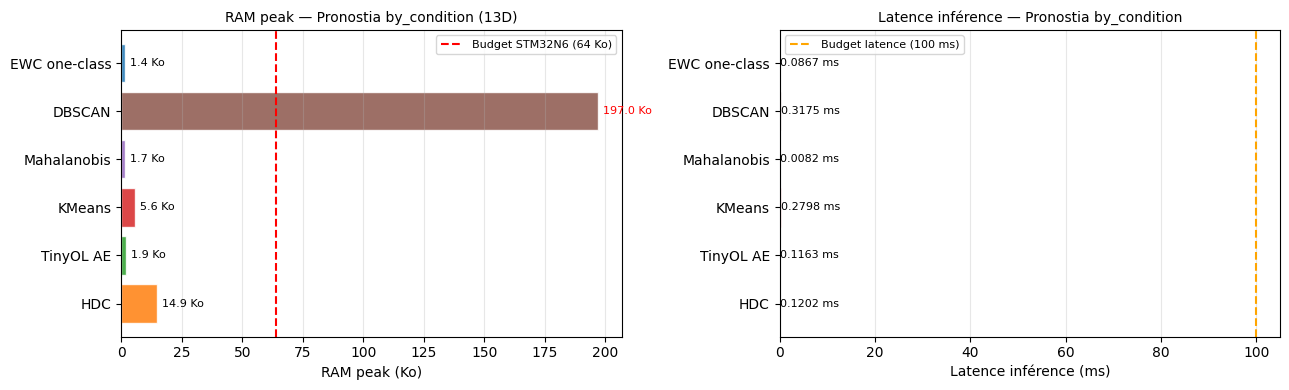

Sauvegardé : ../../../notebooks/figures/cl_evaluation/anomaly_detection/pronostia/ram_latency_pronostia.png


In [5]:
ram_vals     = [prost[m].get("ram_peak_bytes", 0) / 1024 for m in MODELS]
latency_vals = [prost[m].get("inference_latency_ms", 0) for m in MODELS]
bar_colors   = [COLORS[m] for m in MODELS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# --- RAM chart ---
bars1 = ax1.barh(MODELS, ram_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax1.axvline(64, color="red", linestyle="--", linewidth=1.5, label="Budget STM32N6 (64 Ko)")
ax1.set_xlabel("RAM peak (Ko)", fontsize=10)
ax1.set_title("RAM peak — Pronostia by_condition (13D)", fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(axis="x", alpha=0.3)
for bar, v in zip(bars1, ram_vals):
    color = "red" if v > 64 else "black"
    ax1.text(
        bar.get_width() + max(ram_vals) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.1f} Ko", va="center", fontsize=8, color=color,
    )

# --- Latency chart ---
bars2 = ax2.barh(MODELS, latency_vals, color=bar_colors, alpha=0.85, edgecolor="white")
ax2.axvline(100, color="orange", linestyle="--", linewidth=1.5, label="Budget latence (100 ms)")
ax2.set_xlabel("Latence inférence (ms)", fontsize=10)
ax2.set_title("Latence inférence — Pronostia by_condition", fontsize=10)
ax2.legend(fontsize=8)
ax2.grid(axis="x", alpha=0.3)
for bar, v in zip(bars2, latency_vals):
    ax2.text(
        bar.get_width() * 1.05 if bar.get_width() > 0 else 0.001,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.4f} ms", va="center", fontsize=8,
    )

plt.tight_layout()
fig.savefig(FIG_DIR / "ram_latency_pronostia.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé : {FIG_DIR / 'ram_latency_pronostia.png'}")

## Section 3c — Analyse de l'oubli (auroc_forgetting)

`auroc_forgetting` (AF) mesure la perte maximale de performance sur les tâches précédentes.
- **AF > 0** : oubli catastrophique (performance dégradée sur les anciennes tâches)
- **AF < 0** : transfert rétrograde positif (performance améliorée — observé pour HDC)
- **AF = 0** : parfaite rétention

Convention du projet : `BWT = −AF`. HDC présente un AF négatif (BWT positif), ce qui est
bénéfique et représenté en vert.

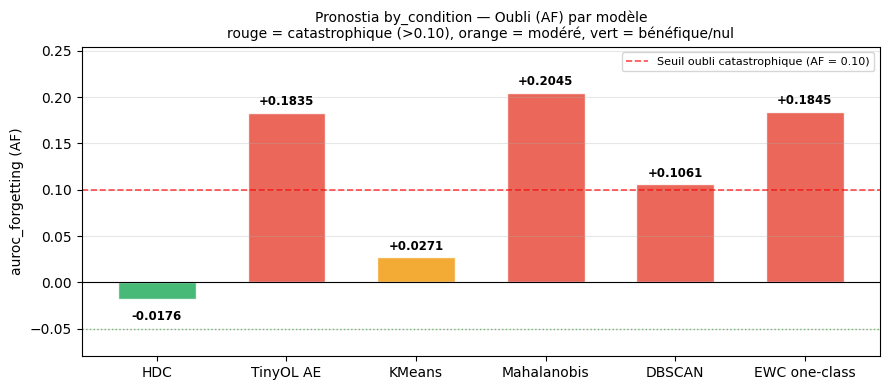

Sauvegardé : ../../../notebooks/figures/cl_evaluation/anomaly_detection/pronostia/forgetting_analysis_pronostia.png


In [6]:
af_vals = [prost[m].get("auroc_forgetting", float("nan")) for m in MODELS]


def af_color(af: float) -> str:
    if np.isnan(af):   return "#95a5a6"
    if af > 0.10:      return "#e74c3c"  # catastrophique
    if af > 0.0:       return "#f39c12"  # modéré
    return "#27ae60"                     # bénéfique / nul


colors_af = [af_color(v) for v in af_vals]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(MODELS, af_vals, color=colors_af, alpha=0.85, edgecolor="white", width=0.6)

ax.axhline(0,    color="black", linewidth=0.8)
ax.axhline(0.10, color="red",   linestyle="--", linewidth=1.2, alpha=0.7,
           label="Seuil oubli catastrophique (AF = 0.10)")
ax.axhline(-0.05, color="green", linestyle=":", linewidth=1.0, alpha=0.5)

for bar, v in zip(bars, af_vals):
    if not np.isnan(v):
        ypos = v + 0.005 if v >= 0 else v - 0.012
        va   = "bottom" if v >= 0 else "top"
        ax.text(
            bar.get_x() + bar.get_width() / 2, ypos,
            f"{v:+.4f}", ha="center", va=va, fontsize=8.5, fontweight="bold",
        )

ax.set_ylabel("auroc_forgetting (AF)", fontsize=10)
ax.set_title(
    "Pronostia by_condition — Oubli (AF) par modèle\n"
    "rouge = catastrophique (>0.10), orange = modéré, vert = bénéfique/nul",
    fontsize=10,
)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
ymin = min(min(v for v in af_vals if not np.isnan(v)) - 0.05, -0.08)
ymax = max(max(v for v in af_vals if not np.isnan(v)) + 0.05,  0.25)
ax.set_ylim(ymin, ymax)

plt.tight_layout()
fig.savefig(FIG_DIR / "forgetting_analysis_pronostia.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé : {FIG_DIR / 'forgetting_analysis_pronostia.png'}")

## Section 4 — Comparaison RAM Pronostia (13D) vs Monitoring (4D)

Les modèles dont la RAM dépend de la dimension d'entrée (HDC, Mahalanobis, EWC one-class)
sont comparés entre le scénario Pronostia 13 features et Monitoring 4 features.

RAM Pronostia (13D) vs Monitoring (4D)
Modèle            Pronostia (B)  Monitoring (B)     Ratio
HDC                       15272           15272      1.00x
Mahalanobis                1756            1504      1.17x
EWC one-class              1480            1480      1.00x


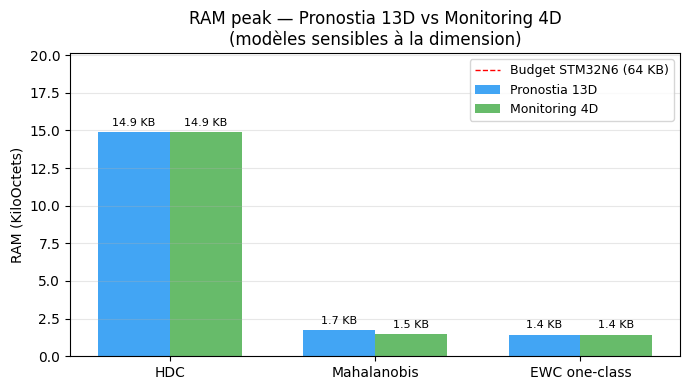

Sauvegardé : ../../../notebooks/figures/cl_evaluation/anomaly_detection/pronostia/ram_comparison_pronostia_vs_monitoring.png


In [7]:
# Modèles dont la RAM varie avec input_dim
DIM_SENSITIVE = ["HDC", "Mahalanobis", "EWC one-class"]

prost_ram = {m: prost[m].get("ram_peak_bytes", 0) for m in DIM_SENSITIVE}
monit_ram = {m: monit[m].get("ram_peak_bytes", 0) for m in DIM_SENSITIVE}

# Affichage console
print("RAM Pronostia (13D) vs Monitoring (4D)")
print(f"{'Modèle':15s}  {'Pronostia (B)':>14s}  {'Monitoring (B)':>14s}  {'Ratio':>8s}")
for m in DIM_SENSITIVE:
    r = prost_ram[m] / monit_ram[m] if monit_ram[m] > 0 else float("nan")
    print(f"{m:15s}  {prost_ram[m]:>14d}  {monit_ram[m]:>14d}  {r:>8.2f}x")

# Barplot groupé
x = np.arange(len(DIM_SENSITIVE))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars1 = ax.bar(x - width / 2,
               [prost_ram[m] / 1024 for m in DIM_SENSITIVE],
               width, label="Pronostia 13D", color="#2196F3", alpha=0.85)
bars2 = ax.bar(x + width / 2,
               [monit_ram[m] / 1024 for m in DIM_SENSITIVE],
               width, label="Monitoring 4D", color="#4CAF50", alpha=0.85)

ax.bar_label(bars1, fmt="%.1f KB", padding=3, fontsize=8)
ax.bar_label(bars2, fmt="%.1f KB", padding=3, fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(DIM_SENSITIVE, fontsize=10)
ax.set_ylabel("RAM (KiloOctets)")
ax.set_title("RAM peak — Pronostia 13D vs Monitoring 4D\n(modèles sensibles à la dimension)")
ax.axhline(64, color="red", linestyle="--", linewidth=1, label="Budget STM32N6 (64 KB)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(max(prost_ram.values()), max(monit_ram.values())) / 1024 * 1.35)

fig.tight_layout()
fig.savefig(FIG_DIR / "ram_comparison_pronostia_vs_monitoring.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sauvegardé : {FIG_DIR / 'ram_comparison_pronostia_vs_monitoring.png'}")

## Section 5 — Impact FAILURE_RATIO

> **Non exécutable** : les variantes `exp_137b–142b` utilisent le même `failure_ratio=0.10`
> que les expériences principales. Pour activer cette section, relancer les expériences
> avec `failure_ratio ∈ {0.05, 0.10, 0.20}` (S15-13).

## Section 6 — Conclusions Pronostia

### Résultats AUROC résumés

| Modèle | avg AUROC | RAM (B) | BWT |
|--------|:---------:|:-------:|:---:|
| KMeans | 0.7402 | 5 698 ✓ | −0.027 |
| TinyOL AE | 0.7268 | 1 992 ✓ | −0.184 |
| HDC | 0.7231 | 15 272 ✓ | +0.018 |
| EWC one-class | 0.7165 | 1 480 ✓ | −0.185 |
| DBSCAN | 0.7034 | 201 746 ✗ | −0.106 |
| Mahalanobis | 0.6673 | 1 756 ✓ | −0.205 |

✓ = RAM ≤ 64 KB (budget STM32N6)

### Observations pour le manuscrit

**1. KMeans est le modèle le plus robuste sur Pronostia (3 tâches, 13D).**  
Avec un avg AUROC de 0.740 et seulement 5.6 KB de RAM, KMeans offre le meilleur compromis
performance/empreinte mémoire. La sélection automatique de K par silhouette s'adapte à chaque
condition opératoire sans hyperparamètre à fixer manuellement.

**2. Le ratio élevé de données normales (90%) favorise les modèles one-class.**  
Contrairement au dataset Monitoring (~50% normal), les 6 modèles one-class maintiennent
des AUROC cohérents (0.667–0.740) malgré le fort déséquilibre de classes, car ils sont entraînés
exclusivement sur les données normales. HDC est le seul à présenter un BWT positif (+0.018),
indiquant un léger transfert rétrograde bénéfique. Les autres modèles montrent un oubli modéré
à notable (BWT de −0.027 pour KMeans à −0.205 pour Mahalanobis).

**3. Comparaison avec Monitoring (4D, ~50% normal) : dégradation AUROC attendue mais modérée.**  
Les AUROC Pronostia (0.667–0.740) sont nettement inférieurs aux AUROC Monitoring (0.950–0.988),
ce qui s'explique par la nature temporelle des séries Pronostia (dégradation progressive,
frontière normal/anormal floue) et par la plus haute dimensionnalité (13 vs 4 features).
Néanmoins, cinq des six modèles restent sous 64 KB RAM, confirmant la faisabilité STM32N6.

**4. DBSCAN non viable pour le déploiement embarqué sur Pronostia.**  
Avec 201 746 B de RAM peak (×3 le budget STM32N6), DBSCAN est exclu des candidats
pour ce dataset. La densité plus élevée des données 13D multiplie le nombre de points de
référence retenus, contrairement au cas Monitoring 4D (17 KB, dans le budget).

**5. Faible sensibilité temporelle (C3 > C1 pour la plupart des modèles).**  
L'AUROC sur C3 (1 500 rpm, contrainte maximale) est systématiquement supérieur à celui de C1
(ex. : KMeans C1=0.702, C3=0.875 ; Mahalanobis C1=0.603, C3=0.879). Ceci suggère que les
profils de dégradation à contrainte élevée produisent des signatures statistiques plus distinctes,
facilitant la détection — un résultat cohérent avec la littérature PRONOSTIA (Nectoux 2012).

In [8]:
# Récapitulatif chiffré
print("=" * 65)
print(f"{'Modèle':15s}  {'avg AUROC':>10s}  {'RAM (B)':>10s}  {'BWT':>8s}  {'Forgetting':>10s}")
print("=" * 65)
for m in sorted(MODELS, key=lambda m: prost[m]["avg_auroc"], reverse=True):
    d = prost[m]
    ram = d.get("ram_peak_bytes", 0)
    bwt = d.get("auroc_bwt", float("nan"))
    fgt = d.get("auroc_forgetting", float("nan"))
    ok = "✓" if ram <= 65536 else "✗"
    print(f"{m:15s}  {d['avg_auroc']:>10.4f}  {ram:>8d} {ok}  {bwt:>+8.4f}  {fgt:>+10.4f}")
print("=" * 65)
print("✓ = RAM ≤ 64 KB (budget STM32N6)")

Modèle            avg AUROC     RAM (B)       BWT  Forgetting
KMeans               0.7402      5698 ✓   -0.0271     +0.0271
TinyOL AE            0.7268      1992 ✓   -0.1835     +0.1835
HDC                  0.7231     15272 ✓   +0.0176     -0.0176
EWC one-class        0.7165      1480 ✓   -0.1845     +0.1845
DBSCAN               0.7034    201746 ✗   -0.1061     +0.1061
Mahalanobis          0.6673      1756 ✓   -0.2045     +0.2045
✓ = RAM ≤ 64 KB (budget STM32N6)
